In [31]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from run_manager import RunViewer


In [32]:
rv = RunViewer(exp_path=this_path.parent)
df_base = rv.fetch_results(met_listed=True, refresh=True)

nested_columns = [name for name, dtype in zip(df_base.columns, df_base.dtypes) if dtype.is_nested()]
df_base = df_base.with_columns([pl.col(name).list.last().alias(f"{name}") for name in nested_columns])

# display(df_base)
print(df_base.columns)

['run_id', 'model_arc', 'train_dataset', 'val_dataset', 'num_classes', 'train_trans', 'val_trans', 'train_ndata', 'val_ndata', 'epochs', 'max_lr', 'batch_size', 'iters/epoch', 'iters', 'target_steps', 'ndata_per_class', 'fils', 'ensembles', 'base_fils', 'criterion', 'optimizer', 'scheduler', 'step', 'epoch', 'train_loss', 'train_acc', 'train_path_loss', 'train_path_acc', 'timestamp', 'timestamp_fmt', 'duration', 'duration_fmt', 'dur_total_core', 'dur_train_core', 'dur_dl_train', 'val_loss', 'val_acc', 'val_path_loss', 'val_path_acc']


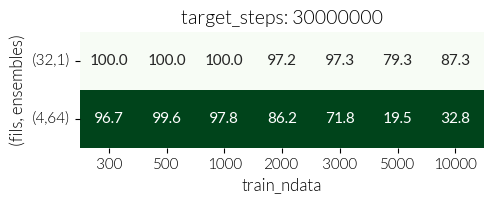

In [40]:
df = df_base

# df = df.filter(pl.col("fils").is_in([32, 16, 8, 4]))

piv_values = ["train_acc"] # 表示する値
piv_index = ["fils", "ensembles"] # 縦軸
piv_on = "train_ndata" # 横軸

# agg = "len"
agg = "mean"

ext_column = "target_steps" # このカラムの要素ごとにheatmapを表示

ext_l = df[ext_column].unique()
for ext in ext_l:
    # pivot table 作成
    df_ext = df.filter(pl.col(ext_column) == ext)
    df_piv = df_ext.pivot(values=piv_values, index=piv_index, on=piv_on, sort_columns=True, aggregate_function=agg)

    # カラムが文字列順になっているため、数字部分をソート
    _num_columns = sorted(int(x) for x in df_piv.columns if x.isdigit())
    new_columns = [str(_num_columns.pop(0)) if x.isdigit() else x for x in df_piv.columns]
    df_piv = df_piv.select(new_columns)

    # (fil, ensemble) の形式に
    df_piv = df_piv.with_columns(("(" + pl.col("fils").cast(pl.String) + "," + pl.col("ensembles").cast(pl.String)).alias("(fils, ensembles)") + ")")
    df_piv = df_piv.select(["(fils, ensembles)"] + new_columns).select(pl.exclude(["fils", "ensembles"]))
    
    # 0列目がx軸ラベル、1列目以降がy軸ラベルになる df を heat map に変換
    square_size = 0.75
    hm_x = df_piv.columns[1:]
    hm_y = df_piv[df_piv.columns[0]]
    data = df_piv.select(hm_x).to_numpy()
    annot = data.copy()

    # 正規化の方向を設定
    axis = 0    # 0: 行方向, 1: 列方向

    # min-max 正規化
    # min_vals = data.min(axis=axis, keepdims=True)
    # max_vals = data.max(axis=axis, keepdims=True)
    # data = (data - min_vals) / (max_vals - min_vals + 1e-8)  # ゼロ除算対策
    
    # Zスコア正規化
    mean_vals = data.mean(axis=axis, keepdims=True)
    std_vals = data.std(axis=axis, keepdims=True)
    data = (data - mean_vals) / (std_vals + 1e-8)  # ゼロ除算対策

    annot *= 100

    fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size))

    fontname = "Lato"
    fontweight = 300  # ここで整数のweightを指定

    hm_kwargs = {
        "cmap": "Greens_r",
        # "cmap": "Blues_r",
        "cbar": False,
        "fmt": ".1f",
        "annot_kws": {"size": 11, "fontname": fontname, "fontweight": 500}
    }

    ax = sns.heatmap(data, annot=annot, square=True, **hm_kwargs)

    ax.set_title(f"{ext_column}: {ext}", fontsize=14, fontname=fontname, fontweight=fontweight)
    ax.set_xlabel(piv_on, fontsize=12, fontname=fontname, fontweight=fontweight)
    ax.set_ylabel(hm_y.name, fontsize=12, rotation=90, fontname=fontname, fontweight=fontweight)

    ax.set_xticklabels(hm_x, fontsize=11, rotation=0)
    for label in ax.get_xticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    ax.set_yticklabels(hm_y, fontsize=11, rotation=0)
    for label in ax.get_yticklabels():
        label.set_fontname(fontname)
        label.set_fontweight(fontweight)

    plt.show()

In [34]:
df = df_base
display(df)


run_id,model_arc,train_dataset,val_dataset,num_classes,train_trans,val_trans,train_ndata,val_ndata,epochs,max_lr,batch_size,iters/epoch,iters,target_steps,ndata_per_class,fils,ensembles,base_fils,criterion,optimizer,scheduler,step,epoch,train_loss,train_acc,train_path_loss,train_path_acc,timestamp,timestamp_fmt,duration,duration_fmt,dur_total_core,dur_train_core,dur_dl_train,val_loss,val_acc,val_path_loss,val_path_acc
i64,str,str,str,i64,str,str,i64,i64,i64,f64,i64,i64,i64,i64,f64,i64,i64,i64,str,str,str,i64,i64,f64,f64,list[f64],list[f64],f64,str,f64,str,f64,f64,f64,f64,f64,list[f64],list[f64]
0,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",10000,10000,3000,0.1,128,79,237000,30000000,100.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",3000,3000,0.427257,0.8728,[0.427257],[0.8728],1.7490e9,"""2025/06/04 08:26:37""",19582.758667,"""5.4h""",1717.815373,1703.014087,193.98985,3.496728,0.411,[3.496728],[0.411]
1,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",10000,10000,3000,0.1,128,79,237000,30000000,100.0,4,64,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",3000,3000,2.885201,0.3277,"[4.605445, 4.605445, … 17.794272]","[0.01, 0.01, … 0.0114]",1.7490e9,"""2025/06/04 08:26:37""",19582.758667,"""5.4h""",17302.74558,17109.507263,193.98985,3.068825,0.2537,"[4.605403, 4.605403, … 23.588155]","[0.01, 0.01, … 0.0113]"
2,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,6000,0.1,128,40,240000,30000000,50.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",6000,6000,0.734136,0.7934,[0.734136],[0.7934],1.7490e9,"""2025/06/04 14:09:16""",20558.91864,"""5.7h""",1757.6278,1742.646029,358.14746,5.588348,0.2513,[5.588348],[0.2513]
3,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",5000,10000,6000,0.1,128,40,240000,30000000,50.0,4,64,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",6000,6000,3.559717,0.1948,"[4.605507, 4.605507, … 4.605507]","[0.01, 0.01, … 0.01]",1.7490e9,"""2025/06/04 14:09:16""",20558.91864,"""5.7h""",17371.455671,17177.829382,358.14746,4.555743,0.0767,"[4.605472, 4.605472, … 4.605472]","[0.01, 0.01, … 0.01]"
4,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",3000,10000,10000,0.1,128,24,240000,30000000,30.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",10000,10000,0.111324,0.973,[0.111324],[0.973],1.7490e9,"""2025/06/04 20:26:44""",22645.936802,"""6.3h""",1799.627595,1784.570138,577.353122,4.670991,0.2574,[4.670991],[0.2574]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",1000,10000,30000,0.1,128,8,240000,30000000,10.0,4,64,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",30000,30000,0.579808,0.978,"[9.099564, 6.842973, … 10.339323]","[0.02, 0.013, … 0.016]",1.7491e9,"""2025/06/05 16:13:36""",45529.562105,"""12.6h""",21060.366795,20817.023664,1705.916255,4.365881,0.0935,"[20.014361, 7.090119, … 7.954495]","[0.0155, 0.01, … 0.0163]"
10,"""ee_tools.models.resnet_git_ee …","""cifar100_train""","""cifar100_val""",100,"""[ToImage(), RandomCrop(size=(3…","""[ToImage(), ToDtype(scale=True…",500,10000,60000,0.1,128,4,240000,30000000,5.0,32,1,32,"""CrossEntropyLoss""","""SGD""","""CosineAnnealingLR""",60000,60000,0.022333,1.0,[0.022333],[1.0],1.7492e9,"""2025/06/06 21:17:47""",104643.604503,"""1.2d""",2526.134821,2511.407172,3270.716601,6.973482,0.08

In [35]:
sr = df_base["val_path_loss"]
sr = sr.list.to_struct(fields=lambda i: f"path_{i}")
df = sr.struct.unnest()
display(df)

path_0
f64
3.496728
4.605403
5.588348
4.605472
4.670991
…
20.014361
6.973482
28.160063
